# Adding in-person data for Chelsea

## I. Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import datetime

## II. Reading in-person data

In [2]:
path = r"..\data\Chelsea_in_person_data\*"
all_files = glob.glob(path)

dataframes = []

for file in all_files:
    df = pd.read_csv(file, delimiter='|')
    dataframes.append(df)

dataframes = pd.concat(dataframes, ignore_index=True)

In [3]:
dataframes.head()

,Record Seq. #,Voter ID Number,Last Name,First Name,Middle Name,Residential Address - Street Number,Residential Address - Street Suffix,Residential Address - Street Name,Residential Address - Apartment Number,Residential Address - Zip Code,...,Mailing Address - City/Town,Mailing Address - State,Mailing Address - Zip Code,Unnamed: 25,Party Affiliation,Residential Address - Street Number,City/ Town Code Assigned Number,Voter Status r,Mailing Address - Zip Code,Unnamed: 24
0,D,06SML2978001,SANTIAGO,MARISOL,NaN,60.0,NaN,PRESCOTT AVE,NaN,2150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,D,03PTE2057000,PHIPPS,TOBEE,L,60.0,NaN,DUDLEY ST,226,21503071,...,CHELSEA,MA,21503071.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,D,04MCR1880000,MILLER,CHRISTOPHER,NaN,41.0,NaN,NAHANT ST,NaN,19023302,...,LYNN,MA,19023302.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,D,08MFK2168001,MCNULTY,FREDERICK,NaN,60.0,NaN,DUDLEY ST,15,2150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,D,01TOR0339000,TICAS,OSCAR,A,9.0,NaN,HOOPER ST,NaN,21503117,...,CHELSEA,MA,21503117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## III. Census Geocoder

### Preparing batch addresses

In [4]:
addresses = pd.DataFrame()

addresses['street'] = round(dataframes['Residential Address - Street Number'].fillna(dataframes['Residential Address - Street Number '])).astype(int).astype(str) + " " + dataframes['Residential Address - Street Name '].str.title()
addresses["city"] = dataframes['City/ Town Name '].str.title()
addresses["state"] = "MA"
addresses["zip_code"] = "0" + dataframes['Residential Address - Zip Code '].astype(str).str[:4]

In [5]:
addresses.head()

,street,city,state,zip_code
0,60 Prescott Ave,Chelsea,MA,02150
1,60 Dudley St,Chelsea,MA,02150
2,41 Nahant St,Chelsea,MA,01902
3,60 Dudley St,Chelsea,MA,02150
4,9 Hooper St,Chelsea,MA,02150


In [6]:
chunk_size = 10000
chunks = [addresses[i:i + chunk_size] for i in range(0, len(addresses), chunk_size)]
for idx, chunk in enumerate(chunks):
    chunk.to_csv(fr'..\data\Chelsea_inperson_addresses\Chelsea_inperson_addresses_{idx + 1}.csv', header=False)

### Reading results

In [7]:
path = r"..\data\Chelsea_inperson_addresses\Chelsea_inperson_tracts\*"

tractslist = []

for file in glob.glob(path):
    df = pd.read_csv(file, header=None)
    tractslist.append(df)

tractslist = pd.concat(tractslist)

In [8]:
tractslist = tractslist.sort_values(by=0)
tractslist.head()

,0,1,2,3,4,5,6,7,8,9,10,11
38,0,"60 Prescott Ave, Chelsea, MA, 02150",Match,Exact,"60 PRESCOTT AVE, CHELSEA, MA, 02150","-71.027532919017,42.401856260772",85707129.0,L,25.0,25.0,160601.0,3003.0
41,1,"60 Dudley St, Chelsea, MA, 02150",Match,Exact,"60 DUDLEY ST, CHELSEA, MA, 02150","-71.021633825431,42.398231693918",85707504.0,L,25.0,25.0,160502.0,5000.0
43,2,"41 Nahant St, Chelsea, MA, 01902",Match,Non_Exact,"41 NAHANT ST, LYNN, MA, 01902","-70.937991729933,42.462280012734",86645955.0,R,25.0,9.0,206900.0,4000.0
45,3,"60 Dudley St, Chelsea, MA, 02150",Match,Exact,"60 DUDLEY ST, CHELSEA, MA, 02150","-71.021633825431,42.398231693918",85707504.0,L,25.0,25.0,160502.0,5000.0
47,4,"9 Hooper St, Chelsea, MA, 02150",Match,Exact,"9 HOOPER ST, CHELSEA, MA, 02150","-71.018932580019,42.400928046421",85707548.0,R,25.0,25.0,160502.0,3013.0


There seem to be many outlier census tracts.

In [9]:
tractslist[10].value_counts()

10
160602.0    11036
160300.0     8901
160501.0     8860
160601.0     7820
160502.0     7417
            ...  
370301.0        1
422301.0        1
382601.0        1
326102.0        1
251700.0        1
Name: count, Length: 795, dtype: int64

## IV. Using results from Geocoder

### Adding coordinates, census tracts to the in-person data

In [10]:
dataframes = dataframes.reset_index(drop=True)
dataframes['geocoding_input'] = tractslist[4].reset_index(drop=True)
dataframes[['longitude', 'latitude']] = tractslist[5].str.split(',', expand=True).reset_index(drop=True)
dataframes['census_tract'] = tractslist[10].reset_index(drop=True)/100
dataframes['outlier'] = ((dataframes['census_tract'] < 1600) | (dataframes['census_tract'] > 1606.02)).astype(int)

In [11]:
dataframes.head()

,Record Seq. #,Voter ID Number,Last Name,First Name,Middle Name,Residential Address - Street Number,Residential Address - Street Suffix,Residential Address - Street Name,Residential Address - Apartment Number,Residential Address - Zip Code,...,Residential Address - Street Number,City/ Town Code Assigned Number,Voter Status r,Mailing Address - Zip Code,Unnamed: 24,geocoding_input,longitude,latitude,census_tract,outlier
0,D,06SML2978001,SANTIAGO,MARISOL,NaN,60.0,NaN,PRESCOTT AVE,NaN,2150,...,NaN,NaN,NaN,NaN,NaN,"60 PRESCOTT AVE, CHELSEA, MA, 02150",-71.027532919017,42.401856260772,1606.01,0
1,D,03PTE2057000,PHIPPS,TOBEE,L,60.0,NaN,DUDLEY ST,226,21503071,...,NaN,NaN,NaN,NaN,NaN,"60 DUDLEY ST, CHELSEA, MA, 02150",-71.021633825431,42.398231693918,1605.02,0
2,D,04MCR1880000,MILLER,CHRISTOPHER,NaN,41.0,NaN,NAHANT ST,NaN,19023302,...,NaN,NaN,NaN,NaN,NaN,"41 NAHANT ST, LYNN, MA, 01902",-70.937991729933,42.462280012734,2069.00,1
3,D,08MFK2168001,MCNULTY,FREDERICK,NaN,60.0,NaN,DUDLEY ST,15,2150,...,NaN,NaN,NaN,NaN,NaN,"60 DUDLEY ST, CHELSEA, MA, 02150",-71.021633825431,42.398231693918,1605.02,0
4,D,01TOR0339000,TICAS,OSCAR,A,9.0,NaN,HOOPER ST,NaN,21503117,...,NaN,NaN,NaN,NaN,NaN,"9 HOOPER ST, CHELSEA, MA, 02150",-71.018932580019,42.400928046421,1605.02,0


Converting to datetime.

In [12]:
pd.to_datetime(dataframes['Election Date '], format='%m/%d/%Y', errors='coerce')

0       2014-09-09
1       2014-09-09
2       2014-09-09
3       2014-09-09
4       2014-09-09
           ...    
64279   2022-11-08
64280   2022-11-08
64281   2022-11-08
64282   2022-11-08
64283   2022-11-08
Name: Election Date , Length: 64284, dtype: datetime64[ns]

### Combining in-person data with our existing (early voting / absentee voting) data

In [13]:
dataframes1 = dataframes[[
    'Last Name ',
    'First Name ',
    'Middle Name ',
    'Voter Title ',
    'Voter ID Number ',
    'Ward Number ',
    'Precinct Number ',
    'Residential Address - Street Name ',
    'Residential Address - Street Number ',
    'Residential Address - Apartment Number ',
    'Election Date ',
    'Record Seq. #',
    'Residential Address - Zip Code ',
    'Party Affiliation ',
    'Voter Status ',
    'geocoding_input',
    'longitude',
    'latitude',
    'census_tract',
    'outlier',
    'Type of Election '
]]
dataframes1.insert(14, "date_of_birth", None)
dataframes1.insert(15, "date_of_registration", None)
dataframes1.insert(16, "congressional_district_number", None)
dataframes1.insert(17, "senatorial_district_number", None)
dataframes1.insert(18, "state_representative_district", None)

In [14]:
dataframes_evav = pd.read_csv(r"C:\Users\taiyo\Downloads\chelsea_tracts_elections.csv")
dataframes_evav = dataframes_evav[dataframes_evav['filename'] != "57VOT_288799.txt"]
dataframes_evav['census_tract'] = dataframes_evav['census_tract'].str.split(n=2).str[-1]
dataframes_evav['filename'] = pd.to_datetime(dataframes_evav['filename'].str.extract(r'(\d{1,2}\.\d{1,2}\.\d{4})')[0], format='%m.%d.%Y')
dataframes_evav['election_type'] = None

In [15]:
dataframes1.columns = dataframes_evav.columns
dataframes_combined = pd.concat([dataframes_evav, dataframes1], ignore_index=True, axis=0)

dataframes_combined['filename'] = pd.to_datetime(dataframes_combined['filename'], errors='coerce')
dataframes_combined['filename'] = dataframes_combined['filename'].dt.strftime('%Y-%m-%d')
dataframes_combined.rename(columns={'filename':'election_date'}, inplace=True)

dataframes_combined.head()

,last_name,first_name,middle_name,title,voter_id_number,ward_number,precinct_number,residential_address_street_name,residential_address_street_number,residential_address_apartment_number,...,congressional_district_number,senatorial_district_number,state_representative_district,voter_status,geocoding_input,longitude,latitude,census_tract,outlier,election_type
0,SELF,JILL,NaN,NaN,10SJL2793000,2,3,WASHINGTON AVE,48.0,105,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507,1,None
1,SELF,JILL,NaN,NaN,10SJL2793000,2,3,WASHINGTON AVE,48.0,105,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507,1,None
2,LEWIS,RUBY,NaN,NaN,06LRY2694000,2,3,WASHINGTON AVE,48.0,202,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507,1,None
3,ALLEN,MCCALL,NaN,NaN,06AML1088000,2,3,WASHINGTON AVE,48.0,108,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507,1,None
4,ALLEN,MCCALL,NaN,NaN,06AML1088000,2,3,WASHINGTON AVE,48.0,108,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507,1,None


In [16]:
dataframes_combined['election_type'].unique()

array([None, 'STATE PRIMARY', 'PRESIDENTIAL PRIMARY', 'LOCAL ELECTION',
       'STATE ELECTION'], dtype=object)

In [17]:
dates_state_primary = dataframes_combined[dataframes_combined['election_type'] == 'STATE PRIMARY']['election_date'].unique()
dates_potus_primary = dataframes_combined[dataframes_combined['election_type'] == 'PRESIDENTIAL PRIMARY']['election_date'].unique()
dates_local_election = dataframes_combined[dataframes_combined['election_type'] == 'LOCAL ELECTION']['election_date'].unique()
dates_state_election = dataframes_combined[dataframes_combined['election_type'] == 'STATE ELECTION']['election_date'].unique()
print(
    dates_state_primary,
    dates_potus_primary,
    dates_local_election,
    dates_state_election
)

['2014-09-09' '2016-09-08' '2018-09-04' '2020-09-01' '2022-09-06'] ['2016-03-01' '2020-03-03'] ['2013-11-05' '2015-09-22' '2015-11-03' '2017-09-26' '2017-11-07'
 '2019-09-24' '2019-11-05' '2021-11-02' '2023-09-26' '2023-11-07'] ['2014-11-04' '2016-11-08' '2018-11-06' '2020-11-03' '2022-11-08']


### Identifying election types
Election type is available in our in-person data. By matching election dates between our two datasets, we are able to identify the election type for 99.3% of rows.  
There are a few dates that are only found in our absentee voting data (amounting to 584 out of 84,897 rows) that we designate as "OTHER" for election type.

In [18]:
for index, row in dataframes_combined.iterrows():
    if pd.isnull(row['election_type']):
        if row['election_date'] in dates_state_primary:
            dataframes_combined.loc[index, 'election_type'] = 'STATE PRIMARY'
        elif row['election_date'] in dates_potus_primary:
            dataframes_combined.loc[index, 'election_type'] = 'PRESIDENTIAL PRIMARY'
        elif row['election_date'] in dates_local_election:
            dataframes_combined.loc[index, 'election_type'] = 'LOCAL ELECTION'
        elif row['election_date'] in dates_state_election:
            dataframes_combined.loc[index, 'election_type'] = 'STATE ELECTION'
        else:
            dataframes_combined.loc[index, 'election_type'] = 'OTHER'

In [19]:
dataframes_combined['census_tract'] = dataframes_combined['census_tract'].astype(float)

In [20]:
dataframes_combined.head()

,last_name,first_name,middle_name,title,voter_id_number,ward_number,precinct_number,residential_address_street_name,residential_address_street_number,residential_address_apartment_number,...,congressional_district_number,senatorial_district_number,state_representative_district,voter_status,geocoding_input,longitude,latitude,census_tract,outlier,election_type
0,SELF,JILL,NaN,NaN,10SJL2793000,2,3,WASHINGTON AVE,48.0,105,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1,STATE ELECTION
1,SELF,JILL,NaN,NaN,10SJL2793000,2,3,WASHINGTON AVE,48.0,105,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1,STATE PRIMARY
2,LEWIS,RUBY,NaN,NaN,06LRY2694000,2,3,WASHINGTON AVE,48.0,202,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1,STATE ELECTION
3,ALLEN,MCCALL,NaN,NaN,06AML1088000,2,3,WASHINGTON AVE,48.0,108,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1,STATE ELECTION
4,ALLEN,MCCALL,NaN,NaN,06AML1088000,2,3,WASHINGTON AVE,48.0,108,...,NaN,NaN,NaN,NaN,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1,STATE PRIMARY


In [21]:
dataframes_combined['election_type'].value_counts()

election_type
STATE ELECTION          41800
STATE PRIMARY           18397
LOCAL ELECTION          14432
PRESIDENTIAL PRIMARY     9684
OTHER                     584
Name: count, dtype: int64

In [22]:
np.mean(dataframes_combined['election_type'] != 'OTHER')

0.9931210761275427

## V. Analyzing the data

### Using less columns
There are some columns that are completely null, since they are only found in "..\57VOT_288799.txt", which is a voter-log table that was cut because it does not represent individual elections. Other columns are also fairly empty.

In [23]:
dataframes_combined.isna().mean()*100

last_name                                 0.000000
first_name                                0.000000
middle_name                              29.433313
title                                    96.998716
voter_id_number                           0.000000
ward_number                               0.000000
precinct_number                           0.000000
residential_address_street_name           0.000000
residential_address_street_number        49.754408
residential_address_apartment_number     35.034218
election_date                             0.001178
rec_sequence_number                      74.034418
residential_address_zip_code             24.280010
party_affiliation                        50.245592
date_of_birth                           100.000000
date_of_registration                    100.000000
congressional_district_number           100.000000
senatorial_district_number              100.000000
state_representative_district           100.000000
voter_status                   

In [24]:
dataframes_log = dataframes_combined[[
    'last_name',
    'first_name',
    'voter_id_number',
    'ward_number',
    'precinct_number',
    'election_date',
    'election_type',
    'geocoding_input',
    'longitude',
    'latitude',
    'census_tract',
    'outlier',
]]
dataframes_log.head()

,last_name,first_name,voter_id_number,ward_number,precinct_number,election_date,election_type,geocoding_input,longitude,latitude,census_tract,outlier
0,SELF,JILL,10SJL2793000,2,3,2020-11-03,STATE ELECTION,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1
1,SELF,JILL,10SJL2793000,2,3,2020-09-01,STATE PRIMARY,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1
2,LEWIS,RUBY,06LRY2694000,2,3,2020-11-03,STATE ELECTION,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1
3,ALLEN,MCCALL,06AML1088000,2,3,2020-11-03,STATE ELECTION,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1
4,ALLEN,MCCALL,06AML1088000,2,3,2020-09-01,STATE PRIMARY,"48 WASHINGTON AVE, CHELSEA, MA, 02150",-71.034739,42.373716,507.0,1


In [25]:
dataframes_log_normal = dataframes_log[dataframes_log['outlier'] == 0]
dataframes_log_normal.drop(columns='outlier', inplace=True)
dataframes_log_normal.head()

C:\Users\taiyo\AppData\Local\Temp\ipykernel_20504\3040873944.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframes_log_normal.drop(columns='outlier', inplace=True)


,last_name,first_name,voter_id_number,ward_number,precinct_number,election_date,election_type,geocoding_input,longitude,latitude,census_tract
27,FOULDS,KENNETH,09FKH1052000,2,1,2016-11-08,STATE ELECTION,"1 BROADWAY, CHELSEA, MA, 02150",-71.045678,42.38681,1603.0
28,FOULDS,KENNETH,09FKH1052000,2,1,2020-11-03,STATE ELECTION,"1 BROADWAY, CHELSEA, MA, 02150",-71.045678,42.38681,1603.0
29,FOULDS,STEPHEN,10FSN1553000,2,1,2020-11-03,STATE ELECTION,"1 BROADWAY, CHELSEA, MA, 02150",-71.045678,42.38681,1603.0
30,FITZGERALD,LUELLA,07FLA0397002,2,1,2018-11-06,STATE ELECTION,"1 WINNISIMMET ST, CHELSEA, MA, 02150",-71.040787,42.386894,1603.0
31,FITZGERALD,LUELLA,07FLA0397002,2,1,2016-11-08,STATE ELECTION,"1 WINNISIMMET ST, CHELSEA, MA, 02150",-71.040787,42.386894,1603.0


In [26]:
dataframes_log_normal['ward_number'] = dataframes_log_normal['ward_number'].astype('int')
dataframes_log_normal['ward_number'].value_counts()

C:\Users\taiyo\AppData\Local\Temp\ipykernel_20504\1568164205.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframes_log_normal['ward_number'] = dataframes_log_normal['ward_number'].astype('int')


ward_number
4     24359
2     23778
3     19761
1     12757
0       151
6        52
5        28
7        10
8        10
11        5
21        2
14        2
17        1
16        1
9         1
Name: count, dtype: int64

In [27]:
dataframes_log_normal = dataframes_log_normal[
    dataframes_log_normal['ward_number'].isin([1,2,3,4])
]

In [28]:
dataframes_log_normal['precinct_number'].value_counts()

precinct_number
1      21456
2      14054
4      13641
3      13628
1       5876
2       4066
3       4006
4       3889
01        10
13         9
11         4
04         3
03         3
02         2
E          2
3A         1
A          1
03A        1
2A         1
C          1
5          1
Name: count, dtype: int64

In [29]:
dataframes_log_normal['precinct_number'].unique()

array([1, 4, 2, 3, '4  ', '2  ', '1  ', '3  ', '13 ', '02 ', '01 ', '3A ',
       'A  ', '11 ', 'E  ', '04 ', '03 ', '03A', '2A ', 'C  ', '5  '],
      dtype=object)

In [30]:
dataframes_log_normal = dataframes_log_normal[
    dataframes_log_normal['precinct_number'].isin([1,2,3,4,'4  ', '2  ', '1  ', '3  '])
]
dataframes_log_normal['precinct_number'] = dataframes_log_normal['precinct_number'].astype('int')

In [31]:
dataframes_log_normal['precinct_number'].value_counts()

precinct_number
1    27332
2    18120
3    17634
4    17530
Name: count, dtype: int64

In [32]:
dataframes_log_normal

,last_name,first_name,voter_id_number,ward_number,precinct_number,election_date,election_type,geocoding_input,longitude,latitude,census_tract
27,FOULDS,KENNETH,09FKH1052000,2,1,2016-11-08,STATE ELECTION,"1 BROADWAY, CHELSEA, MA, 02150",-71.045678,42.38681,1603.00
28,FOULDS,KENNETH,09FKH1052000,2,1,2020-11-03,STATE ELECTION,"1 BROADWAY, CHELSEA, MA, 02150",-71.045678,42.38681,1603.00
29,FOULDS,STEPHEN,10FSN1553000,2,1,2020-11-03,STATE ELECTION,"1 BROADWAY, CHELSEA, MA, 02150",-71.045678,42.38681,1603.00
30,FITZGERALD,LUELLA,07FLA0397002,2,1,2018-11-06,STATE ELECTION,"1 WINNISIMMET ST, CHELSEA, MA, 02150",-71.040787,42.386894,1603.00
31,FITZGERALD,LUELLA,07FLA0397002,2,1,2016-11-08,STATE ELECTION,"1 WINNISIMMET ST, CHELSEA, MA, 02150",-71.040787,42.386894,1603.00
...,...,...,...,...,...,...,...,...,...,...,...
84892,RIVERA,LUIS,07RLS2546000,2,2,2022-11-08,STATE ELECTION,"67 6TH ST, CHELSEA, MA, 02150",-71.03548153395,42.396370750763,1605.01
84893,MARTINEZ,TERESA,12MTA1255001,1,2,2022-11-08,STATE ELECTION,"56 MAVERICK ST, CHELSEA, MA, 02150",-71.03248119609,42.388977449783,1601.03
84894,CARDONA,ALEXANDER,08CAR2979000,4,1,2022-11-08,STATE ELECTION,"100 STOCKTON ST, CHELSEA, MA, 02150",-71.022379654128,42.401736026436,1606.01
84895,CARDONA,ANA,12AAA1787000,4,1,2022-11-08,STATE ELECTION,"100 STOCKTON ST, CHELSEA, MA, 02150",-71.022379654128,42.401736026436,1606.01


In [33]:
dataframes_log_normal.set_index([
    'voter_id_number', 
    'last_name', 
    'first_name', 
    'ward_number', 
    'precinct_number',
    'geocoding_input',
    'longitude',
    'latitude',
    'census_tract',
])

election_date  \
voter_id_number last_name  first_name ward_number precinct_number geocoding_input                      longitude        latitude        census_tract                 
09FKH1052000    FOULDS     KENNETH    2           1               1 BROADWAY, CHELSEA, MA, 02150       -71.04567808     42.38680989     1603.00         2016-11-08   
                                                                                                                                        1603.00         2020-11-03   
10FSN1553000    FOULDS     STEPHEN    2           1               1 BROADWAY, CHELSEA, MA, 02150       -71.04567808     42.38680989     1603.00         2020-11-03   
07FLA0397002    FITZGERALD LUELLA     2           1               1 WINNISIMMET ST, CHELSEA, MA, 02150 -71.04078673     42.3868937      1603.00         2018-11-06   
                                                                                                                                        1603.00         2016-11-08   
...                                                                                                                                                            ...   
07RLS2546000    RIVERA     LUIS       2           2               67 6TH ST, CHELSEA, MA, 02150        -71.03548153395  42.396370750763 1605.01         2022-11-08   
12MTA1255001    MARTINEZ   TERESA     1           2               56 MAVERICK ST, CHELSEA, MA, 02150   -71.03248119609  42.388977449783 1601.03         2022-11-08   
08CAR2979000    CARDONA    ALEXANDER  4           1               100 STOCKTON ST, CHELSEA, MA, 02150  -71.022379654128 42.401736026436 1606.01         2022-11-08   
12AAA1787000    CARDONA    ANA        4           1               100 STOCKTON ST, CHELSEA, MA, 02150  -71.022379654128 42.401736026436 1606.01         2022-11-08   
05CEY1296000    CRABTREE   EMILY      2           1               36 MEDFORD ST, CHELSEA, MA, 02150    -71.043164064332 42.387359825176 1603.00         2022-11-08   

                                                                                                                                                       election_type  
voter_id_number last_name  first_name ward_number precinct_number geocoding_input                      longitude        latitude        census_tract                  
09FKH1052000    FOULDS     KENNETH    2           1               1 BROADWAY, CHELSEA, MA, 02150       -71.04567808     42.38680989     1603.00       STATE ELECTION  
                                                                                                                                        1603.00       STATE ELECTION  
10FSN1553000    FOULDS     STEPHEN    2           1               1 BROADWAY, CHELSEA, MA, 02150       -71.04567808     42.38680989     1603.00       STATE ELECTION  
07FLA0397002    FITZGERALD LUELLA     2           1               1 WINNISIMMET ST, CHELSEA, MA, 02150 -71.04078673     42.3868937      1603.00       STATE ELECTION  
                                                                                                                                        1603.00       STATE ELECTION  
...                                                                                                                                                              ...  
07RLS2546000    RIVERA     LUIS       2           2               67 6TH ST, CHELSEA, MA, 02150        -71.03548153395  42.396370750763 1605.01       STATE ELECTION  
12MTA1255001    MARTINEZ   TERESA     1           2               56 MAVERICK ST, CHELSEA, MA, 02150   -71.03248119609  42.388977449783 1601.03       STATE ELECTION  
08CAR2979000    CARDONA    ALEXANDER  4           1               100 STOCKTON ST, CHELSEA, MA, 02150  -71.022379654128 42.401736026436 1606.01       STATE ELECTION  
12AAA1787000    CARDONA    ANA        4           1               100 STOCKTON ST, CHELSEA, MA, 02150  -71.022379654128 42.401736026436 1606.01       STA

In [34]:
# Pivoting by election_date and election_type
pivot_df = dataframes_log_normal.pivot_table(
    index='voter_id_number', 
    columns='election_date', 
    values='election_type', 
    aggfunc='first', 
    fill_value=None
)

pivot_df = pivot_df.map(lambda x: 'YES' if pd.notnull(x) else 'no')

pivot_df['Total'] = (pivot_df == 'YES').sum(axis=1)

pivot_df.reset_index(inplace=True)

pivot_df

election_date,voter_id_number,2013-04-30,2013-06-25,2013-09-24,2013-11-05,2013-12-01,2014-03-04,2014-04-01,2014-09-09,2014-11-04,...,2020-09-01,2020-11-03,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total
0,01AAA2259001,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,YES,no,no,no,1
1,01AAA3148000,no,no,no,YES,no,no,no,no,no,...,YES,YES,no,no,no,no,YES,no,no,9
2,01AAD0368000,no,no,no,no,no,no,no,no,no,...,no,YES,no,no,no,no,no,no,no,1
3,01AAE1580000,no,no,no,no,no,no,no,no,no,...,no,YES,no,no,no,no,no,no,no,1
4,01AAE2867000,no,YES,no,YES,no,no,no,YES,YES,...,no,no,no,no,no,no,no,no,no,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,no,no,no,no,no,no,no,no,no,...,YES,YES,no,YES,no,YES,YES,no,no,12
14644,12ZLY1359000,no,no,no,YES,no,no,no,no,YES,...,no,no,no,no,no,no,no,no,no,5
14645,12ZNS0657000,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,YES,1
14646,12ZRD1040000,no,no,no,no,no,no,no,no,YES,...,YES,YES,no,no,no,no,YES,no,no,8


Here, I aggregate voter data, taking their last ward/precinct/census tract if necessary (e.g. a voter relocated within Chelsea).

In [35]:
df_voter_precincts = dataframes_log_normal[['voter_id_number', 'last_name', 'first_name', 'ward_number', 'precinct_number', 'census_tract', 'latitude', 'longitude']]
df_voter_precincts = df_voter_precincts.groupby('voter_id_number').agg('last').reset_index()
df_voter_precincts

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,latitude,longitude
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,42.390154720593,-71.037917954987
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,42.389274858685,-71.047913148314
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,42.404068101295,-71.033634172647
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,42.389274858685,-71.047913148314
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,42.397917960824,-71.031821270249
...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,42.390148147575,-71.04592576334
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,42.388214517373,-71.032182743089
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,42.391986562272,-71.037586468088
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,42.389032589416,-71.044390715209


In [36]:
df_voter_precincts['ward_number'] = df_voter_precincts['ward_number'].astype(str).str.strip().str.lstrip('0')
df_voter_precincts['precinct_number'] = df_voter_precincts['precinct_number'].astype(str).str.strip().str.lstrip('0')

My naming convention for dataframes has been frankly messy. The final dataframe (with which our group can perform analysis) will be `df_final_log` (a final table that acts as a voter log).

In [37]:
df_final_log = df_voter_precincts.merge(pivot_df, on='voter_id_number', how='left')
df_final_log

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,latitude,longitude,2013-04-30,2013-06-25,...,2020-09-01,2020-11-03,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,42.390154720593,-71.037917954987,no,no,...,no,no,no,no,no,YES,no,no,no,1
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,42.389274858685,-71.047913148314,no,no,...,YES,YES,no,no,no,no,YES,no,no,9
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,42.404068101295,-71.033634172647,no,no,...,no,YES,no,no,no,no,no,no,no,1
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,42.389274858685,-71.047913148314,no,no,...,no,YES,no,no,no,no,no,no,no,1
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,42.397917960824,-71.031821270249,no,YES,...,no,no,no,no,no,no,no,no,no,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,42.390148147575,-71.04592576334,no,no,...,YES,YES,no,YES,no,YES,YES,no,no,12
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,42.388214517373,-71.032182743089,no,no,...,no,no,no,no,no,no,no,no,no,5
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,42.391986562272,-71.037586468088,no,no,...,no,no,no,no,no,no,no,no,YES,1
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,42.389032589416,-71.044390715209,no,no,...,YES,YES,no,no,no,no,YES,no,no,8


## VI. Adding demographics

### 1. Household Income

In [38]:
df_income = pd.read_csv(r'..\data\Chelsea_Census\urbanleague-Chelsea-Census-income.csv')

In [39]:
df_income1 = df_income[[
    'Census Tract 1601.02; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate',
    'Census Tract 1601.03; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate',
    'Census Tract 1602; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate',
    'Census Tract 1603; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate',
    'Census Tract 1604; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate',
    'Census Tract 1605.01; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate',
    'Census Tract 1605.02; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate',
    'Census Tract 1606.01; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate',
    'Census Tract 1606.02; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate',
]]
df_income1.rename(columns={
    'Census Tract 1601.02; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate': float(1601.02),
    'Census Tract 1601.03; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate': float(1601.03),
    'Census Tract 1602; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate': float(1602.00),
    'Census Tract 1603; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate': float(1603.00),
    'Census Tract 1604; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate': float(1604.00),
    'Census Tract 1605.01; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate': float(1605.01),
    'Census Tract 1605.02; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate': float(1605.02),
    'Census Tract 1606.01; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate': float(1606.01),
    'Census Tract 1606.02; Suffolk County; Massachusetts!!Median income (dollars)!!Estimate': float(1606.02), 
},
    inplace=True
)

C:\Users\taiyo\AppData\Local\Temp\ipykernel_20504\239262958.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_income1.rename(columns={


In [40]:
income_by_tract = df_income1.iloc[1:2]
income_by_tract = income_by_tract.replace(',','', regex=True).astype(int)
income_by_tract = income_by_tract.T.rename(columns={1:'median_household_income'})
income_by_tract.reset_index(inplace=True)
income_by_tract.rename(columns={'index':'census_tract'}, inplace=True)
income_by_tract

,census_tract,median_household_income
0,1601.02,67500
1,1601.03,80573
2,1602.00,73889
3,1603.00,75417
4,1604.00,74329
5,1605.01,59625
6,1605.02,55568
7,1606.01,108605
8,1606.02,75985


In [41]:
df_final_log = df_final_log.merge(income_by_tract, on='census_tract', how='left')
col = df_final_log.pop('median_household_income')
df_final_log.insert(5, 'median_household_income', col)
df_final_log

,voter_id_number,last_name,first_name,ward_number,precinct_number,median_household_income,census_tract,latitude,longitude,2013-04-30,...,2020-09-01,2020-11-03,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total
0,01AAA2259001,AVILA,ALBA,2,4,73889.0,1602.00,42.390154720593,-71.037917954987,no,...,no,no,no,no,no,YES,no,no,no,1
1,01AAA3148000,ARSENAULT,ANITA,2,1,75417.0,1603.00,42.389274858685,-71.047913148314,no,...,YES,YES,no,no,no,no,YES,no,no,9
2,01AAD0368000,ATOUI,AHMAD,4,3,75985.0,1606.02,42.404068101295,-71.033634172647,no,...,no,YES,no,no,no,no,no,no,no,1
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,75417.0,1603.00,42.389274858685,-71.047913148314,no,...,no,YES,no,no,no,no,no,no,no,1
4,01AAE2867000,ADAMS,ANNIE,3,4,59625.0,1605.01,42.397917960824,-71.031821270249,no,...,no,no,no,no,no,no,no,no,no,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,75417.0,1603.00,42.390148147575,-71.04592576334,no,...,YES,YES,no,YES,no,YES,YES,no,no,12
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,80573.0,1601.03,42.388214517373,-71.032182743089,no,...,no,no,no,no,no,no,no,no,no,5
14645,12ZNS0657000,ZEP,NICOLAS,2,3,74329.0,1604.00,42.391986562272,-71.037586468088,no,...,no,no,no,no,no,no,no,no,YES,1
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,75417.0,1603.00,42.389032589416,-71.044390715209,no,...,YES,YES,no,no,no,no,YES,no,no,8


In [42]:
income_by_precinct = df_final_log[['ward_number', 'precinct_number', 'median_household_income']].groupby(['ward_number', 'precinct_number']).mean()
income_by_precinct.reset_index(inplace=True)
income_by_precinct

,ward_number,precinct_number,median_household_income
0,1,1,78641.382239
1,1,2,78876.394366
2,1,3,73366.724784
3,1,4,67869.202840
4,2,1,75370.588486
5,2,2,67861.350932
6,2,3,74165.424723
7,2,4,74450.260483
8,3,1,78198.694792
9,3,2,55789.695887


In [43]:
df_final_log = df_final_log.drop(columns=['median_household_income']).merge(income_by_precinct, on=['ward_number', 'precinct_number'], how='left')
col = df_final_log.pop('median_household_income')
df_final_log.insert(6, 'median_household_income', col)
df_final_log

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,median_household_income,latitude,longitude,2013-04-30,...,2020-09-01,2020-11-03,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,74450.260483,42.390154720593,-71.037917954987,no,...,no,no,no,no,no,YES,no,no,no,1
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,75370.588486,42.389274858685,-71.047913148314,no,...,YES,YES,no,no,no,no,YES,no,no,9
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,75956.357285,42.404068101295,-71.033634172647,no,...,no,YES,no,no,no,no,no,no,no,1
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,75370.588486,42.389274858685,-71.047913148314,no,...,no,YES,no,no,no,no,no,no,no,1
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,60042.606667,42.397917960824,-71.031821270249,no,...,no,no,no,no,no,no,no,no,no,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,75370.588486,42.390148147575,-71.04592576334,no,...,YES,YES,no,YES,no,YES,YES,no,no,12
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,78641.382239,42.388214517373,-71.032182743089,no,...,no,no,no,no,no,no,no,no,no,5
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,74165.424723,42.391986562272,-71.037586468088,no,...,no,no,no,no,no,no,no,no,YES,1
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,75370.588486,42.389032589416,-71.044390715209,no,...,YES,YES,no,no,no,no,YES,no,no,8


### 2. Race

In [44]:
df_pop = pd.read_csv(r'..\data\Chelsea_Census\census_data_race_ethnicity.csv')

In [45]:
df_pop = df_pop.T
df_pop.columns = df_pop.iloc[0]
df_pop = df_pop[1:]
df_pop

Unnamed: 0,Massachusetts,Census Tract 3421.01,Census Tract 3424.01,Census Tract 3425.01,Census Tract 507,Census Tract 1601.02,Census Tract 1601.03,Census Tract 1602,Census Tract 1603,Census Tract 1604,Census Tract 1605.01,Census Tract 1605.02,Census Tract 1606.01,Census Tract 1606.02,Census Tract 1703.01
total_population,7029917,5028,4604,4740,4520,3823,4646,4154,2753,3878,6105,5604,4331,5493,7045
total_population_one_race,6421050,4255,3834,3704,3635,3180,3772,3605,2503,3334,4959,4656,3642,4648,6068
white_alone,4896037,2081,1583,1602,1565,654,1051,708,1657,1017,1243,1510,1563,1780,4292
black_alone,494029,724,624,644,127,365,282,182,241,295,330,366,353,582,259
american_indian_alone,24018,37,41,10,53,46,68,71,22,46,91,109,62,61,40
asian_alone,507934,341,354,287,126,91,108,47,139,186,117,215,185,251,389
native_hawaiian_alone,2301,0,3,4,5,0,0,2,0,0,4,5,2,3,6
other_race_alone,496731,1072,1229,1157,1759,2024,2263,2595,444,1790,3174,2451,1477,1971,1082
two_more_races,608867,773,770,1036,885,643,874,549,250,544,1146,948,689,845,977
total_race,7680780,5830,5390,5816,5433,4487,5564,4716,3015,4438,7304,6644,5094,6376,8043


In [46]:
df_pop1 = df_pop.copy()
df_pop1.drop(columns={'Massachusetts'}, inplace=True)
df_pop1.columns = df_pop1.columns.str.replace('Census Tract ', '').str.strip()
df_pop1.drop(columns={
    '3421.01', '3424.01', '3425.01', '507', '1703.01'
}, inplace=True)
df_pop1

Unnamed: 0,1601.02,1601.03,1602,1603,1604,1605.01,1605.02,1606.01,1606.02
total_population,3823,4646,4154,2753,3878,6105,5604,4331,5493
total_population_one_race,3180,3772,3605,2503,3334,4959,4656,3642,4648
white_alone,654,1051,708,1657,1017,1243,1510,1563,1780
black_alone,365,282,182,241,295,330,366,353,582
american_indian_alone,46,68,71,22,46,91,109,62,61
asian_alone,91,108,47,139,186,117,215,185,251
native_hawaiian_alone,0,0,2,0,0,4,5,2,3
other_race_alone,2024,2263,2595,444,1790,3174,2451,1477,1971
two_more_races,643,874,549,250,544,1146,948,689,845
total_race,4487,5564,4716,3015,4438,7304,6644,5094,6376


In [47]:
df_pop2 = df_pop1.copy()
df_pop2 = df_pop2.iloc[12:,:]

In [48]:
df_pop3 = df_pop2.T.reset_index()
df_pop3 = df_pop3.rename(columns={
    "Unnamed: 0": "census_tract"
})
df_pop3['census_tract'] = df_pop3['census_tract'].astype('float64')
df_pop3

,census_tract,total_population_one_race_percent,white_alone_percent,black_alone_percent,american_indian_alone_percent,asian_alone_percent,native_hawaiian_alone_percent,other_race_alone_percent,two_more_races_percent,hispanic_population_percent,non_hispanic_population_percent
0,1601.02,83.2,17.1,9.5,1.2,2.4,0.0,52.9,16.8,73.3,26.7
1,1601.03,81.2,22.6,6.1,1.5,2.3,0.0,48.7,18.8,74.8,25.2
2,1602.00,86.8,17.0,4.4,1.7,1.1,0.0,62.5,13.2,83.7,16.3
3,1603.00,90.9,60.2,8.8,0.8,5.0,0.0,16.1,9.1,26.6,73.4
4,1604.00,86.0,26.2,7.6,1.2,4.8,0.0,46.2,14.0,63.4,36.6
5,1605.01,81.2,20.4,5.4,1.5,1.9,0.1,52.0,18.8,78.5,21.5
6,1605.02,83.1,26.9,6.5,1.9,3.8,0.1,43.7,16.9,67.5,32.5
7,1606.01,84.1,36.1,8.2,1.4,4.3,0.0,34.1,15.9,54.8,45.2
8,1606.02,84.6,32.4,10.6,1.1,4.6,0.1,35.9,15.4,53.4,46.6


In [49]:
df_pop3.columns

Index(['census_tract', 'total_population_one_race_percent',
       'white_alone_percent', 'black_alone_percent',
       'american_indian_alone_percent', 'asian_alone_percent',
       'native_hawaiian_alone_percent', 'other_race_alone_percent',
       'two_more_races_percent', 'hispanic_population_percent',
       'non_hispanic_population_percent'],
      dtype='object')

In [50]:
df_final_log = df_final_log.merge(df_pop3, on='census_tract', how='left')
df_final_log

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,median_household_income,latitude,longitude,2013-04-30,...,total_population_one_race_percent,white_alone_percent,black_alone_percent,american_indian_alone_percent,asian_alone_percent,native_hawaiian_alone_percent,other_race_alone_percent,two_more_races_percent,hispanic_population_percent,non_hispanic_population_percent
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,74450.260483,42.390154720593,-71.037917954987,no,...,86.8,17.0,4.4,1.7,1.1,0.0,62.5,13.2,83.7,16.3
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,75370.588486,42.389274858685,-71.047913148314,no,...,90.9,60.2,8.8,0.8,5.0,0.0,16.1,9.1,26.6,73.4
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,75956.357285,42.404068101295,-71.033634172647,no,...,84.6,32.4,10.6,1.1,4.6,0.1,35.9,15.4,53.4,46.6
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,75370.588486,42.389274858685,-71.047913148314,no,...,90.9,60.2,8.8,0.8,5.0,0.0,16.1,9.1,26.6,73.4
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,60042.606667,42.397917960824,-71.031821270249,no,...,81.2,20.4,5.4,1.5,1.9,0.1,52.0,18.8,78.5,21.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,75370.588486,42.390148147575,-71.04592576334,no,...,90.9,60.2,8.8,0.8,5.0,0.0,16.1,9.1,26.6,73.4
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,78641.382239,42.388214517373,-71.032182743089,no,...,81.2,22.6,6.1,1.5,2.3,0.0,48.7,18.8,74.8,25.2
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,74165.424723,42.391986562272,-71.037586468088,no,...,86.0,26.2,7.6,1.2,4.8,0.0,46.2,14.0,63.4,36.6
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,75370.588486,42.389032589416,-71.044390715209,no,...,90.9,60.2,8.8,0.8,5.0,0.0,16.1,9.1,26.6,73.4


In [51]:
race_by_precinct = df_final_log[[
    'ward_number',
    'precinct_number',
    'total_population_one_race_percent',
       'white_alone_percent', 'black_alone_percent',
       'american_indian_alone_percent', 'asian_alone_percent',
       'native_hawaiian_alone_percent', 'other_race_alone_percent',
       'two_more_races_percent', 'hispanic_population_percent',
       'non_hispanic_population_percent'
]].groupby(['ward_number', 'precinct_number']).mean()
race_by_precinct.reset_index(inplace=True)
race_by_precinct

,ward_number,precinct_number,total_population_one_race_percent,white_alone_percent,black_alone_percent,american_indian_alone_percent,asian_alone_percent,native_hawaiian_alone_percent,other_race_alone_percent,two_more_races_percent,hispanic_population_percent,non_hispanic_population_percent
0,1,1,82.519562,21.462548,5.794595,1.541055,2.067954,0.001287,51.626898,17.480438,76.475032,23.524968
1,1,2,82.665594,21.298994,5.697586,1.547082,2.015091,0.000201,52.081288,17.334406,76.850101,23.149899
2,1,3,82.69438,19.361527,7.672911,1.36585,2.254179,0.000144,51.980548,17.30562,74.773199,25.226801
3,1,4,83.359838,17.567546,9.3643,1.203651,2.512779,0.000203,52.616836,16.640162,72.871805,27.128195
4,2,1,90.666951,58.6,8.742697,0.81935,4.985128,0.000107,17.51967,9.333049,28.343284,71.656716
5,2,2,83.878054,23.670911,6.649586,1.33147,3.5206,0.044513,48.705383,16.121946,70.001863,29.998137
6,2,3,86.330111,22.833281,6.378447,1.389857,3.381933,0.0,52.308241,13.669889,71.01046,28.98954
7,2,4,87.73723,31.937738,6.571283,1.300254,3.272554,0.0,44.612579,12.26277,61.618424,38.381576
8,3,1,83.304063,29.972813,7.083437,1.642813,3.789792,0.058021,40.676146,16.695937,63.478854,36.521146
9,3,2,83.113312,26.936255,6.519372,1.894805,3.805844,0.099567,43.659307,16.886688,67.417857,32.582143


In [52]:
df_final_log = df_final_log.drop(columns=[
    'total_population_one_race_percent',
       'white_alone_percent', 'black_alone_percent',
       'american_indian_alone_percent', 'asian_alone_percent',
       'native_hawaiian_alone_percent', 'other_race_alone_percent',
       'two_more_races_percent', 'hispanic_population_percent',
       'non_hispanic_population_percent'
]).merge(race_by_precinct, on=['ward_number', 'precinct_number'], how='left')

In [53]:
df_final_log

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,median_household_income,latitude,longitude,2013-04-30,...,total_population_one_race_percent,white_alone_percent,black_alone_percent,american_indian_alone_percent,asian_alone_percent,native_hawaiian_alone_percent,other_race_alone_percent,two_more_races_percent,hispanic_population_percent,non_hispanic_population_percent
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,74450.260483,42.390154720593,-71.037917954987,no,...,87.73723,31.937738,6.571283,1.300254,3.272554,0.0,44.612579,12.26277,61.618424,38.381576
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,75370.588486,42.389274858685,-71.047913148314,no,...,90.666951,58.6,8.742697,0.81935,4.985128,0.000107,17.51967,9.333049,28.343284,71.656716
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,75956.357285,42.404068101295,-71.033634172647,no,...,84.596108,32.394012,10.583333,1.100898,4.592715,0.0998,35.92515,15.403892,53.444711,46.555289
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,75370.588486,42.389274858685,-71.047913148314,no,...,90.666951,58.6,8.742697,0.81935,4.985128,0.000107,17.51967,9.333049,28.343284,71.656716
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,60042.606667,42.397917960824,-71.031821270249,no,...,81.341333,20.588889,5.469333,1.492111,1.987778,0.097222,51.802556,18.658667,78.028222,21.971778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,75370.588486,42.390148147575,-71.04592576334,no,...,90.666951,58.6,8.742697,0.81935,4.985128,0.000107,17.51967,9.333049,28.343284,71.656716
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,78641.382239,42.388214517373,-71.032182743089,no,...,82.519562,21.462548,5.794595,1.541055,2.067954,0.001287,51.626898,17.480438,76.475032,23.524968
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,74165.424723,42.391986562272,-71.037586468088,no,...,86.330111,22.833281,6.378447,1.389857,3.381933,0.0,52.308241,13.669889,71.01046,28.98954
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,75370.588486,42.389032589416,-71.044390715209,no,...,90.666951,58.6,8.742697,0.81935,4.985128,0.000107,17.51967,9.333049,28.343284,71.656716


In [54]:
df_final_log.columns

Index(['voter_id_number', 'last_name', 'first_name', 'ward_number',
       'precinct_number', 'census_tract', 'median_household_income',
       'latitude', 'longitude', '2013-04-30', '2013-06-25', '2013-09-24',
       '2013-11-05', '2013-12-01', '2014-03-04', '2014-04-01', '2014-09-09',
       '2014-11-04', '2015-09-22', '2015-11-03', '2016-01-31', '2016-03-01',
       '2016-09-08', '2016-11-08', '2017-09-26', '2017-11-07', '2018-09-04',
       '2018-11-06', '2019-09-24', '2019-11-05', '2020-03-03', '2020-09-01',
       '2020-11-03', '2021-09-21', '2021-11-02', '2022-01-25', '2022-09-06',
       '2022-11-08', '2023-09-26', '2023-11-07', 'Total',
       'total_population_one_race_percent', 'white_alone_percent',
       'black_alone_percent', 'american_indian_alone_percent',
       'asian_alone_percent', 'native_hawaiian_alone_percent',
       'other_race_alone_percent', 'two_more_races_percent',
       'hispanic_population_percent', 'non_hispanic_population_percent'],
      dtype='objec

In [55]:
# Get column names
cols = list(df_final_log.columns)

# Identify last 10 columns
last_10 = cols[-10:]

# Identify columns before position 6
before_6 = cols[:6]

# Identify remaining columns after moving last 10
after_6 = cols[6:-10]

# Reorder columns
new_order = before_6 + last_10 + after_6

# Apply new column order to the DataFrame
df_final_log = df_final_log[new_order]
df_final_log

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,total_population_one_race_percent,white_alone_percent,black_alone_percent,american_indian_alone_percent,...,2020-09-01,2020-11-03,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,87.73723,31.937738,6.571283,1.300254,...,no,no,no,no,no,YES,no,no,no,1
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,YES,YES,no,no,no,no,YES,no,no,9
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,84.596108,32.394012,10.583333,1.100898,...,no,YES,no,no,no,no,no,no,no,1
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,no,YES,no,no,no,no,no,no,no,1
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,81.341333,20.588889,5.469333,1.492111,...,no,no,no,no,no,no,no,no,no,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,YES,YES,no,YES,no,YES,YES,no,no,12
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,82.519562,21.462548,5.794595,1.541055,...,no,no,no,no,no,no,no,no,no,5
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,86.330111,22.833281,6.378447,1.389857,...,no,no,no,no,no,no,no,no,YES,1
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,YES,YES,no,no,no,no,YES,no,no,8


In [56]:
demographics_by_precinct = income_by_precinct.merge(race_by_precinct, on=['ward_number', 'precinct_number'], how='left')
demographics_by_precinct

,ward_number,precinct_number,median_household_income,total_population_one_race_percent,white_alone_percent,black_alone_percent,american_indian_alone_percent,asian_alone_percent,native_hawaiian_alone_percent,other_race_alone_percent,two_more_races_percent,hispanic_population_percent,non_hispanic_population_percent
0,1,1,78641.382239,82.519562,21.462548,5.794595,1.541055,2.067954,0.001287,51.626898,17.480438,76.475032,23.524968
1,1,2,78876.394366,82.665594,21.298994,5.697586,1.547082,2.015091,0.000201,52.081288,17.334406,76.850101,23.149899
2,1,3,73366.724784,82.69438,19.361527,7.672911,1.36585,2.254179,0.000144,51.980548,17.30562,74.773199,25.226801
3,1,4,67869.202840,83.359838,17.567546,9.3643,1.203651,2.512779,0.000203,52.616836,16.640162,72.871805,27.128195
4,2,1,75370.588486,90.666951,58.6,8.742697,0.81935,4.985128,0.000107,17.51967,9.333049,28.343284,71.656716
5,2,2,67861.350932,83.878054,23.670911,6.649586,1.33147,3.5206,0.044513,48.705383,16.121946,70.001863,29.998137
6,2,3,74165.424723,86.330111,22.833281,6.378447,1.389857,3.381933,0.0,52.308241,13.669889,71.01046,28.98954
7,2,4,74450.260483,87.73723,31.937738,6.571283,1.300254,3.272554,0.0,44.612579,12.26277,61.618424,38.381576
8,3,1,78198.694792,83.304063,29.972813,7.083437,1.642813,3.789792,0.058021,40.676146,16.695937,63.478854,36.521146
9,3,2,55789.695887,83.113312,26.936255,6.519372,1.894805,3.805844,0.099567,43.659307,16.886688,67.417857,32.582143


In [57]:
demographics_by_precinct.to_csv('..\data\Chelsea_demographics_by_precinct.csv')

In [58]:
df57 = pd.read_csv(
    r"..\data\Chelse PRR_Voter Data 10 Years (2013-2023)\57VOT_288799.txt",
    delimiter="|",
    encoding="latin1"
)
df57.rename(columns={
    'Voter ID Number ': 'voter_id_number',
    'Date of Birth ': 'date_of_birth',
    'Date of Registration ': 'date_of_registration'
}, inplace=True)
df57 = df57[['voter_id_number', 'date_of_birth', 'date_of_registration']]
df57

,voter_id_number,date_of_birth,date_of_registration
0,09PRE1618001,09/18/1916,02/12/2020
1,08KHN2520000,08/25/1920,10/14/1997
2,03LHY0622001,03/06/1922,08/20/2020
3,10NCN2025000,10/20/1925,03/18/2016
4,07ZAE2826000,07/28/1926,05/15/1972
...,...,...,...
17890,12YEA1604001,12/16/2004,12/29/2022
17891,02TRN2305000,02/23/2005,08/19/2022
17892,05HJE0805000,05/08/2005,12/14/2023
17893,07MGA1305000,07/13/2005,11/08/2023


In [59]:
df_final_log = df_final_log.merge(df57, on='voter_id_number', how='left')
df_final_log

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,total_population_one_race_percent,white_alone_percent,black_alone_percent,american_indian_alone_percent,...,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total,date_of_birth,date_of_registration
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,87.73723,31.937738,6.571283,1.300254,...,no,no,no,YES,no,no,no,1,01/22/1959,02/11/2022
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,no,no,no,no,YES,no,no,9,01/31/1948,05/15/1988
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,84.596108,32.394012,10.583333,1.100898,...,no,no,no,no,no,no,no,1,01/03/1968,09/04/2020
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,no,no,no,no,no,no,no,1,01/15/1980,04/18/2017
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,81.341333,20.588889,5.469333,1.492111,...,no,no,no,no,no,no,no,7,01/28/1967,05/15/1972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,no,YES,no,YES,YES,no,no,12,12/05/1943,09/03/2015
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,82.519562,21.462548,5.794595,1.541055,...,no,no,no,no,no,no,no,5,NaN,NaN
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,86.330111,22.833281,6.378447,1.389857,...,no,no,no,no,no,no,YES,1,12/06/1957,07/03/2023
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,no,no,no,no,YES,no,no,8,NaN,NaN


In [60]:
df_final_log['date_of_birth'] = pd.to_datetime(df_final_log['date_of_birth'])
df_final_log['date_of_registration'] = pd.to_datetime(df_final_log['date_of_registration'])

In [61]:
df_final_log

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,total_population_one_race_percent,white_alone_percent,black_alone_percent,american_indian_alone_percent,...,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total,date_of_birth,date_of_registration
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,87.73723,31.937738,6.571283,1.300254,...,no,no,no,YES,no,no,no,1,1959-01-22,2022-02-11
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,no,no,no,no,YES,no,no,9,1948-01-31,1988-05-15
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,84.596108,32.394012,10.583333,1.100898,...,no,no,no,no,no,no,no,1,1968-01-03,2020-09-04
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,no,no,no,no,no,no,no,1,1980-01-15,2017-04-18
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,81.341333,20.588889,5.469333,1.492111,...,no,no,no,no,no,no,no,7,1967-01-28,1972-05-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,no,YES,no,YES,YES,no,no,12,1943-12-05,2015-09-03
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,82.519562,21.462548,5.794595,1.541055,...,no,no,no,no,no,no,no,5,NaT,NaT
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,86.330111,22.833281,6.378447,1.389857,...,no,no,no,no,no,no,YES,1,1957-12-06,2023-07-03
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,90.666951,58.6,8.742697,0.81935,...,no,no,no,no,YES,no,no,8,NaT,NaT


In [62]:
df_final_log.columns

Index(['voter_id_number', 'last_name', 'first_name', 'ward_number',
       'precinct_number', 'census_tract', 'total_population_one_race_percent',
       'white_alone_percent', 'black_alone_percent',
       'american_indian_alone_percent', 'asian_alone_percent',
       'native_hawaiian_alone_percent', 'other_race_alone_percent',
       'two_more_races_percent', 'hispanic_population_percent',
       'non_hispanic_population_percent', 'median_household_income',
       'latitude', 'longitude', '2013-04-30', '2013-06-25', '2013-09-24',
       '2013-11-05', '2013-12-01', '2014-03-04', '2014-04-01', '2014-09-09',
       '2014-11-04', '2015-09-22', '2015-11-03', '2016-01-31', '2016-03-01',
       '2016-09-08', '2016-11-08', '2017-09-26', '2017-11-07', '2018-09-04',
       '2018-11-06', '2019-09-24', '2019-11-05', '2020-03-03', '2020-09-01',
       '2020-11-03', '2021-09-21', '2021-11-02', '2022-01-25', '2022-09-06',
       '2022-11-08', '2023-09-26', '2023-11-07', 'Total', 'date_of_birth',
  

In [63]:
cols = list(df_final_log.columns)
df_final_log = df_final_log[cols[:6] + cols[-2:] + cols[6:-2]]
df_final_log

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,date_of_birth,date_of_registration,total_population_one_race_percent,white_alone_percent,...,2020-09-01,2020-11-03,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,1959-01-22,2022-02-11,87.73723,31.937738,...,no,no,no,no,no,YES,no,no,no,1
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,1948-01-31,1988-05-15,90.666951,58.6,...,YES,YES,no,no,no,no,YES,no,no,9
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,1968-01-03,2020-09-04,84.596108,32.394012,...,no,YES,no,no,no,no,no,no,no,1
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,1980-01-15,2017-04-18,90.666951,58.6,...,no,YES,no,no,no,no,no,no,no,1
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,1967-01-28,1972-05-15,81.341333,20.588889,...,no,no,no,no,no,no,no,no,no,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,1943-12-05,2015-09-03,90.666951,58.6,...,YES,YES,no,YES,no,YES,YES,no,no,12
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,NaT,NaT,82.519562,21.462548,...,no,no,no,no,no,no,no,no,no,5
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,1957-12-06,2023-07-03,86.330111,22.833281,...,no,no,no,no,no,no,no,no,YES,1
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,NaT,NaT,90.666951,58.6,...,YES,YES,no,no,no,no,YES,no,no,8


In [64]:
df_final_log2 = df_final_log.copy()
df_final_log2

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,date_of_birth,date_of_registration,total_population_one_race_percent,white_alone_percent,...,2020-09-01,2020-11-03,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,1959-01-22,2022-02-11,87.73723,31.937738,...,no,no,no,no,no,YES,no,no,no,1
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,1948-01-31,1988-05-15,90.666951,58.6,...,YES,YES,no,no,no,no,YES,no,no,9
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,1968-01-03,2020-09-04,84.596108,32.394012,...,no,YES,no,no,no,no,no,no,no,1
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,1980-01-15,2017-04-18,90.666951,58.6,...,no,YES,no,no,no,no,no,no,no,1
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,1967-01-28,1972-05-15,81.341333,20.588889,...,no,no,no,no,no,no,no,no,no,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,1943-12-05,2015-09-03,90.666951,58.6,...,YES,YES,no,YES,no,YES,YES,no,no,12
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,NaT,NaT,82.519562,21.462548,...,no,no,no,no,no,no,no,no,no,5
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,1957-12-06,2023-07-03,86.330111,22.833281,...,no,no,no,no,no,no,no,no,YES,1
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,NaT,NaT,90.666951,58.6,...,YES,YES,no,no,no,no,YES,no,no,8


In [65]:
df_final_log2['date_of_eligibility'] = df_final_log2['date_of_birth'] + pd.DateOffset(years=18)
df_final_log2

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,date_of_birth,date_of_registration,total_population_one_race_percent,white_alone_percent,...,2020-11-03,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total,date_of_eligibility
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,1959-01-22,2022-02-11,87.73723,31.937738,...,no,no,no,no,YES,no,no,no,1,1977-01-22
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,1948-01-31,1988-05-15,90.666951,58.6,...,YES,no,no,no,no,YES,no,no,9,1966-01-31
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,1968-01-03,2020-09-04,84.596108,32.394012,...,YES,no,no,no,no,no,no,no,1,1986-01-03
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,1980-01-15,2017-04-18,90.666951,58.6,...,YES,no,no,no,no,no,no,no,1,1998-01-15
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,1967-01-28,1972-05-15,81.341333,20.588889,...,no,no,no,no,no,no,no,no,7,1985-01-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,1943-12-05,2015-09-03,90.666951,58.6,...,YES,no,YES,no,YES,YES,no,no,12,1961-12-05
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,NaT,NaT,82.519562,21.462548,...,no,no,no,no,no,no,no,no,5,NaT
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,1957-12-06,2023-07-03,86.330111,22.833281,...,no,no,no,no,no,no,no,YES,1,1975-12-06
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,NaT,NaT,90.666951,58.6,...,YES,no,no,no,no,YES,no,no,8,NaT


In [66]:
election_columns = df_final_log2.columns[21:52]
election_list = []
for election in election_columns:
    election_list.append(pd.Timestamp(f'{election}'))
election_list

[Timestamp('2013-04-30 00:00:00'),
 Timestamp('2013-06-25 00:00:00'),
 Timestamp('2013-09-24 00:00:00'),
 Timestamp('2013-11-05 00:00:00'),
 Timestamp('2013-12-01 00:00:00'),
 Timestamp('2014-03-04 00:00:00'),
 Timestamp('2014-04-01 00:00:00'),
 Timestamp('2014-09-09 00:00:00'),
 Timestamp('2014-11-04 00:00:00'),
 Timestamp('2015-09-22 00:00:00'),
 Timestamp('2015-11-03 00:00:00'),
 Timestamp('2016-01-31 00:00:00'),
 Timestamp('2016-03-01 00:00:00'),
 Timestamp('2016-09-08 00:00:00'),
 Timestamp('2016-11-08 00:00:00'),
 Timestamp('2017-09-26 00:00:00'),
 Timestamp('2017-11-07 00:00:00'),
 Timestamp('2018-09-04 00:00:00'),
 Timestamp('2018-11-06 00:00:00'),
 Timestamp('2019-09-24 00:00:00'),
 Timestamp('2019-11-05 00:00:00'),
 Timestamp('2020-03-03 00:00:00'),
 Timestamp('2020-09-01 00:00:00'),
 Timestamp('2020-11-03 00:00:00'),
 Timestamp('2021-09-21 00:00:00'),
 Timestamp('2021-11-02 00:00:00'),
 Timestamp('2022-01-25 00:00:00'),
 Timestamp('2022-09-06 00:00:00'),
 Timestamp('2022-11-

In [67]:
df_final_log2['earliest_eligible_election'] = None
for index in range(len(df_final_log2)):
    for i in range(len(election_list)):
        if df_final_log2.loc[index, 'date_of_eligibility'] <= election_list[i]:
            df_final_log2.loc[index, 'earliest_eligible_election'] = election_list[i]
            break

In [68]:
df_final_log2

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,date_of_birth,date_of_registration,total_population_one_race_percent,white_alone_percent,...,2021-09-21,2021-11-02,2022-01-25,2022-09-06,2022-11-08,2023-09-26,2023-11-07,Total,date_of_eligibility,earliest_eligible_election
0,01AAA2259001,AVILA,ALBA,2,4,1602.00,1959-01-22,2022-02-11,87.73723,31.937738,...,no,no,no,YES,no,no,no,1,1977-01-22,2013-04-30 00:00:00
1,01AAA3148000,ARSENAULT,ANITA,2,1,1603.00,1948-01-31,1988-05-15,90.666951,58.6,...,no,no,no,no,YES,no,no,9,1966-01-31,2013-04-30 00:00:00
2,01AAD0368000,ATOUI,AHMAD,4,3,1606.02,1968-01-03,2020-09-04,84.596108,32.394012,...,no,no,no,no,no,no,no,1,1986-01-03,2013-04-30 00:00:00
3,01AAE1580000,AKINKUOLIE,AKINTUNDE,2,1,1603.00,1980-01-15,2017-04-18,90.666951,58.6,...,no,no,no,no,no,no,no,1,1998-01-15,2013-04-30 00:00:00
4,01AAE2867000,ADAMS,ANNIE,3,4,1605.01,1967-01-28,1972-05-15,81.341333,20.588889,...,no,no,no,no,no,no,no,7,1985-01-28,2013-04-30 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14643,12ZIO0543001,ZALDANA,ISIDRO,2,1,1603.00,1943-12-05,2015-09-03,90.666951,58.6,...,no,YES,no,YES,YES,no,no,12,1961-12-05,2013-04-30 00:00:00
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03,NaT,NaT,82.519562,21.462548,...,no,no,no,no,no,no,no,5,NaT,None
14645,12ZNS0657000,ZEP,NICOLAS,2,3,1604.00,1957-12-06,2023-07-03,86.330111,22.833281,...,no,no,no,no,no,no,YES,1,1975-12-06,2013-04-30 00:00:00
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00,NaT,NaT,90.666951,58.6,...,no,no,no,no,YES,no,no,8,NaT,None


In [69]:
(df_final_log2['date_of_eligibility'] > pd.Timestamp('2013-01-01'))

0        False
1        False
2        False
3        False
4        False
         ...  
14643    False
14644    False
14645    False
14646    False
14647    False
Name: date_of_eligibility, Length: 14648, dtype: bool

(array([9.926e+03, 1.290e+02, 2.650e+02, 1.140e+02, 1.450e+02, 1.510e+02,
        2.020e+02, 9.300e+01, 7.300e+01, 8.000e+00]),
 array([15825. , 16205.1, 16585.2, 16965.3, 17345.4, 17725.5, 18105.6,
        18485.7, 18865.8, 19245.9, 19626. ]),
 <BarContainer object of 10 artists>)

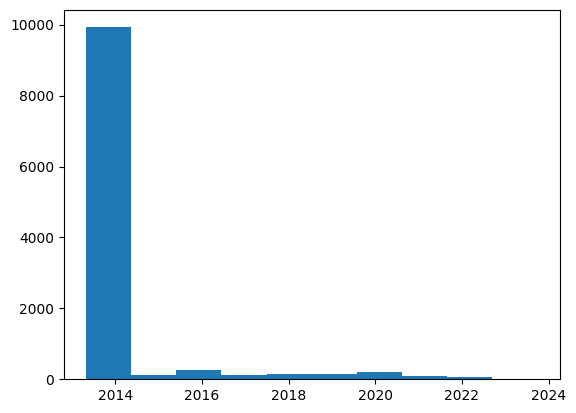

In [70]:
plt.hist(df_final_log2['earliest_eligible_election'])

In [71]:
df_final_log2.to_csv('..\data\Chelsea_final_table.csv')

### Creating an "unpivoted" version of the above table

In [72]:
# Unpivot the dataframe
df_unpivoted = df_final_log2.melt(
    id_vars=[col for col in df_final_log2.columns if not col.startswith('20')],  # Keep non-date columns
    var_name='date',  # New column for dates
    value_name='status'  # New column for "YES"/"no"
)

# Filter rows where status is "YES"
df_unpivoted = df_unpivoted[df_unpivoted['date'] >= df_unpivoted['earliest_eligible_election']]
#df_unpivoted[df_unpivoted['status'] == 'YES']

# Drop the 'status' column as it's no longer needed
df_unpivoted = df_unpivoted.drop(columns=['Total'])

# Convert the 'date' column to datetime format (optional)
df_unpivoted['date'] = pd.to_datetime(df_unpivoted['date'])

# Display the result
df_unpivoted = df_unpivoted.sort_values(by='voter_id_number')

df_unpivoted

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,date_of_birth,date_of_registration,total_population_one_race_percent,white_alone_percent,...,two_more_races_percent,hispanic_population_percent,non_hispanic_population_percent,median_household_income,latitude,longitude,date_of_eligibility,earliest_eligible_election,date,status
0,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,12.26277,61.618424,38.381576,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2013-04-30,no
410144,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,12.26277,61.618424,38.381576,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2022-11-08,no
395496,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,12.26277,61.618424,38.381576,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2022-09-06,YES
380848,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,12.26277,61.618424,38.381576,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2022-01-25,no
14648,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,12.26277,61.618424,38.381576,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2013-06-25,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205069,12ZNS0657000,ZEP,NICOLAS,2,3,1604.0,1957-12-06,2023-07-03,86.330111,22.833281,...,13.669889,71.01046,28.98954,74165.424723,42.391986562272,-71.037586468088,1975-12-06,2013-04-30,2016-09-08,no
43941,12ZNS0657000,ZEP,NICOLAS,2,3,1604.0,1957-12-06,2023-07-03,86.330111,22.833281,...,13.669889,71.01046,28.98954,74165.424723,42.391986562272,-71.037586468088,1975-12-06,2013-04-30,2013-09-24,no
439437,12ZNS0657000,ZEP,NICOLAS,2,3,1604.0,1957-12-06,2023-07-03,86.330111,22.833281,...,13.669889,71.01046,28.98954,74165.424723,42.391986562272,-71.037586468088,1975-12-06,2013-04-30,2023-09-26,no
87885,12ZNS0657000,ZEP,NICOLAS,2,3,1604.0,1957-12-06,2023-07-03,86.330111,22.833281,...,13.669889,71.01046,28.98954,74165.424723,42.391986562272,-71.037586468088,1975-12-06,2013-04-30,2014-03-04,no


In [73]:
df_unpivoted['status'] = df_unpivoted['status'].map({'YES': 1, 'no': 0})

In [74]:
df_unpivoted.drop('non_hispanic_population_percent', axis=1)

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,date_of_birth,date_of_registration,total_population_one_race_percent,white_alone_percent,...,other_race_alone_percent,two_more_races_percent,hispanic_population_percent,median_household_income,latitude,longitude,date_of_eligibility,earliest_eligible_election,date,status
0,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,44.612579,12.26277,61.618424,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2013-04-30,0
410144,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,44.612579,12.26277,61.618424,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2022-11-08,0
395496,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,44.612579,12.26277,61.618424,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2022-09-06,1
380848,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,44.612579,12.26277,61.618424,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2022-01-25,0
14648,01AAA2259001,AVILA,ALBA,2,4,1602.0,1959-01-22,2022-02-11,87.73723,31.937738,...,44.612579,12.26277,61.618424,74450.260483,42.390154720593,-71.037917954987,1977-01-22,2013-04-30,2013-06-25,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205069,12ZNS0657000,ZEP,NICOLAS,2,3,1604.0,1957-12-06,2023-07-03,86.330111,22.833281,...,52.308241,13.669889,71.01046,74165.424723,42.391986562272,-71.037586468088,1975-12-06,2013-04-30,2016-09-08,0
43941,12ZNS0657000,ZEP,NICOLAS,2,3,1604.0,1957-12-06,2023-07-03,86.330111,22.833281,...,52.308241,13.669889,71.01046,74165.424723,42.391986562272,-71.037586468088,1975-12-06,2013-04-30,2013-09-24,0
439437,12ZNS0657000,ZEP,NICOLAS,2,3,1604.0,1957-12-06,2023-07-03,86.330111,22.833281,...,52.308241,13.669889,71.01046,74165.424723,42.391986562272,-71.037586468088,1975-12-06,2013-04-30,2023-09-26,0
87885,12ZNS0657000,ZEP,NICOLAS,2,3,1604.0,1957-12-06,2023-07-03,86.330111,22.833281,...,52.308241,13.669889,71.01046,74165.424723,42.391986562272,-71.037586468088,1975-12-06,2013-04-30,2014-03-04,0


In [75]:
df_unpivoted['status'] = df_unpivoted['status'].astype(int)

In [76]:
df_unpivoted['ward_number'] = df_unpivoted['ward_number'].astype(str)
df_unpivoted['precinct_number'] = df_unpivoted['precinct_number'].astype(str)

In [ ]:
#df_unpivoted.to_csv("..\data\Chelsea_final_table_unpivoted.csv")

In [ ]:
#df_unpivoted.to_excel("..\data\Chelsea_final_table_unpivoted.xlsx")

## Identifying voters with missing DOB and Date of Registration

In [79]:
# Filter rows with NaT in 'date_of_birth'
rows_with_nat = df_unpivoted[df_unpivoted['date_of_birth'].isna()]

# Check if there are rows with the same 'last_name' and 'first_name' but non-null 'date_of_birth'
matches = rows_with_nat.apply(
    lambda row: df_unpivoted[
        (df_unpivoted['last_name'] == row['last_name']) &
        (df_unpivoted['first_name'] == row['first_name']) &
        (df_unpivoted['date_of_birth'].notna())
    ].shape[0] > 0,
    axis=1
)

# Add a column to indicate if a match was found
rows_with_nat['has_match'] = matches

# Display the result
rows_with_nat

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract,date_of_birth,date_of_registration,total_population_one_race_percent,white_alone_percent,...,hispanic_population_percent,non_hispanic_population_percent,median_household_income,latitude,longitude,date_of_eligibility,earliest_eligible_election,date,status,has_match


In [80]:
rows_with_nat['has_match'].sum()

0.0

In [81]:
df_missing = df_final_log[df_final_log['date_of_birth'].isna()][df_final_log.columns[:6]]
df_missing

,voter_id_number,last_name,first_name,ward_number,precinct_number,census_tract
11,01AAS2883005,ANDRADE,AMARILIS,4,2,1606.02
27,01AGA2895002,ARACENA BURGOS,GILDA,3,1,1605.02
28,01AHR0665001,AVILES,HECTOR,2,4,1602.00
36,01AJE1288000,ALCANTAR,JOSE,1,3,1601.03
39,01AJN3185001,ALLWEIN,JOHN,2,2,1604.00
...,...,...,...,...,...,...
14632,12WWM2150000,WRIGHT,WILLIAM,3,2,1605.02
14637,12ZAY2198000,ZELAYA,ANDY,2,2,1604.00
14644,12ZLY1359000,ZBIKOWSKI,LUCY,1,1,1601.03
14646,12ZRD1040000,ZUNIGA,RONALD,2,1,1603.00


In [82]:
# Confirming that we are missing this data
df_missing['voter_id_number'].isin(df57['voter_id_number']).sum()

0

In [83]:
df_missing.to_csv('..\data\Chelsea_no_dates.csv')